# Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset.

## Introduction
- To perform descriptive analytics, visualize data distributions, and preprocess the dataset for further analysis.


In [1]:
# Importing Libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## Descriptive Analytics for Numerical Columns

In [2]:
# Loading the dataset from a CSV File.
# convert Date column to datetime.- dates are DD‑MM‑YYYY.

df = pd.read_csv("sales_data_with_discounts.csv",parse_dates=['Date'],dayfirst=True)
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2021-04-01,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,2021-04-01,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,2021-04-01,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,2021-04-01,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,2021-04-01,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [3]:
df.shape # coloumn, rows

(450, 13)

In [4]:
# To get information about data types and null values.
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               450 non-null    datetime64[us]
 1   Day                450 non-null    str           
 2   SKU                450 non-null    str           
 3   City               450 non-null    str           
 4   Volume             450 non-null    int64         
 5   BU                 450 non-null    str           
 6   Brand              450 non-null    str           
 7   Model              450 non-null    str           
 8   Avg Price          450 non-null    int64         
 9   Total Sales Value  450 non-null    int64         
 10  Discount Rate (%)  450 non-null    float64       
 11  Discount Amount    450 non-null    float64       
 12  Net Sales Value    450 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(6)
memory usage: 45.8 KB


In [5]:
# remove exact duplicate rows
df.drop_duplicates(inplace=True)

# strip whitespace from column names & object columns
df.columns = df.columns.str.strip()
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

In [6]:
# Identifing the columns types in the dataset.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [7]:
# To get statistical summary of numeric data.
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Date,450,2021-04-08 00:00:00,2021-04-01 00:00:00,2021-04-04 00:00:00,2021-04-08 00:00:00,2021-04-12 00:00:00,2021-04-15 00:00:00,NaN
Volume,450.0,5.066667,1.0,3.0,4.0,6.0,31.0,4.231602
Avg Price,450.0,10453.433333,290.0,465.0,1450.0,10100.0,60100.0,18079.90484
Total Sales Value,450.0,33812.835556,400.0,2700.0,5700.0,53200.0,196400.0,50535.074173
Discount Rate (%),450.0,15.155242,5.007822,13.965063,16.577766,18.114718,19.992407,4.220602
Discount Amount,450.0,3346.499424,69.177942,460.459304,988.933733,5316.495427,25738.022194,4509.902963
Net Sales Value,450.0,30466.336131,326.974801,2202.208645,4677.788059,47847.912852,179507.479049,46358.656624


In [8]:
# Descriptive statistics.
desc_stats = pd.DataFrame({
    'Mean'   : df[numeric_cols].mean(),
    'Median' : df[numeric_cols].median(),
    'Mode'   : df[numeric_cols].apply(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    'StdDev' : df[numeric_cols].std(),
    'Skew'   : df[numeric_cols].skew()
})
print('*** Descriptive Statistics (Numerical Columns) ***')
print(desc_stats)

*** Descriptive Statistics (Numerical Columns) ***
                           Mean       Median          Mode        StdDev  \
Volume                 5.066667     4.000000      3.000000      4.231602   
Avg Price          10453.433333  1450.000000    400.000000  18079.904840   
Total Sales Value  33812.835556  5700.000000  24300.000000  50535.074173   
Discount Rate (%)     15.155242    16.577766      5.007822      4.220602   
Discount Amount     3346.499424   988.933733     69.177942   4509.902963   
Net Sales Value    30466.336131  4677.788059    326.974801  46358.656624   

                       Skew  
Volume             2.731724  
Avg Price          1.908873  
Total Sales Value  1.534729  
Discount Rate (%) -1.062294  
Discount Amount    1.913038  
Net Sales Value    1.540822  


## Data Visualization

### Histograms :

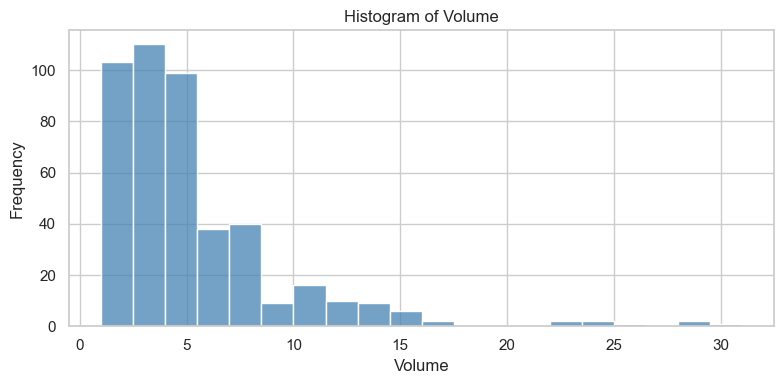

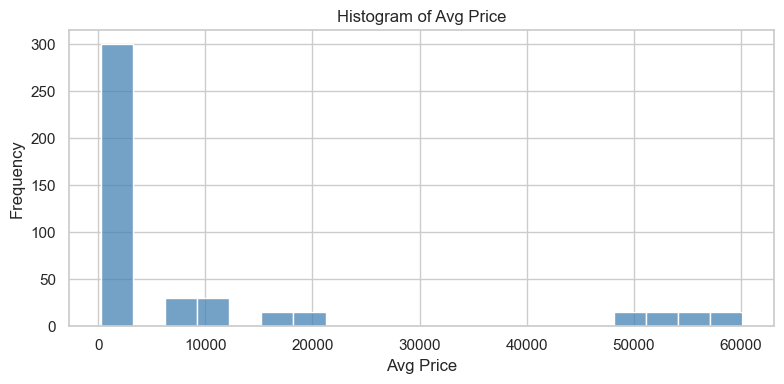

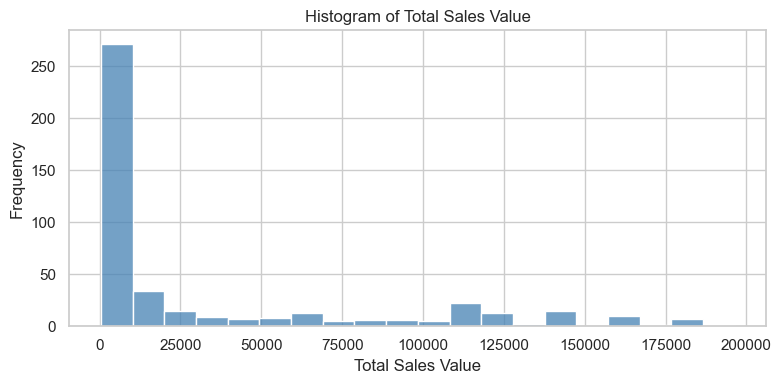

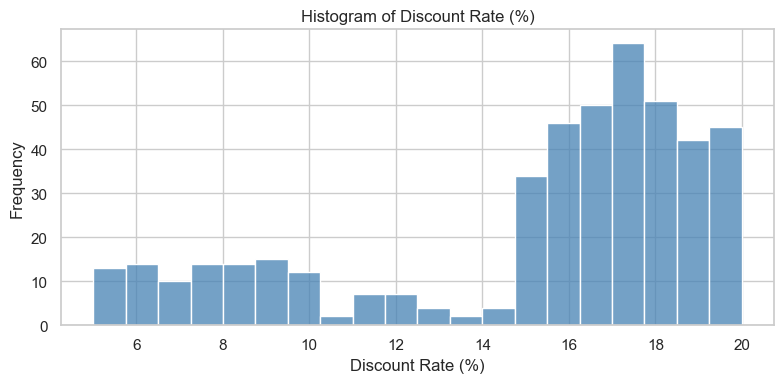

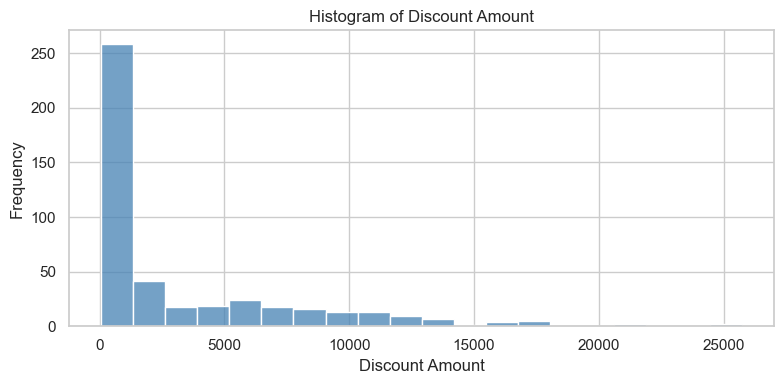

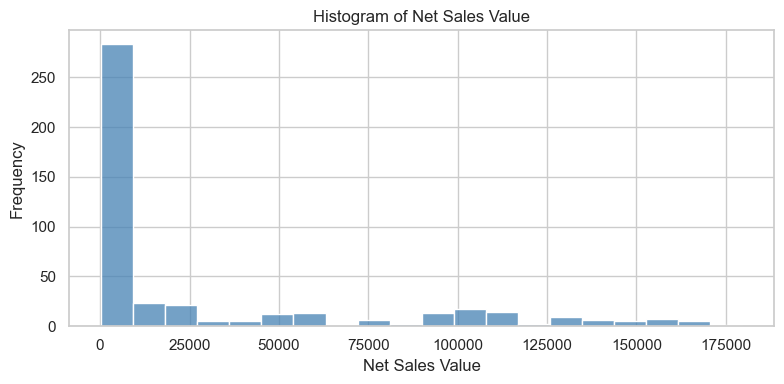

In [9]:
# Histograms:
'''Ploting histograms for each numerical column & Analyze the distribution '''

sns.set(style='whitegrid')
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=20, kde=False, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Box Plots :

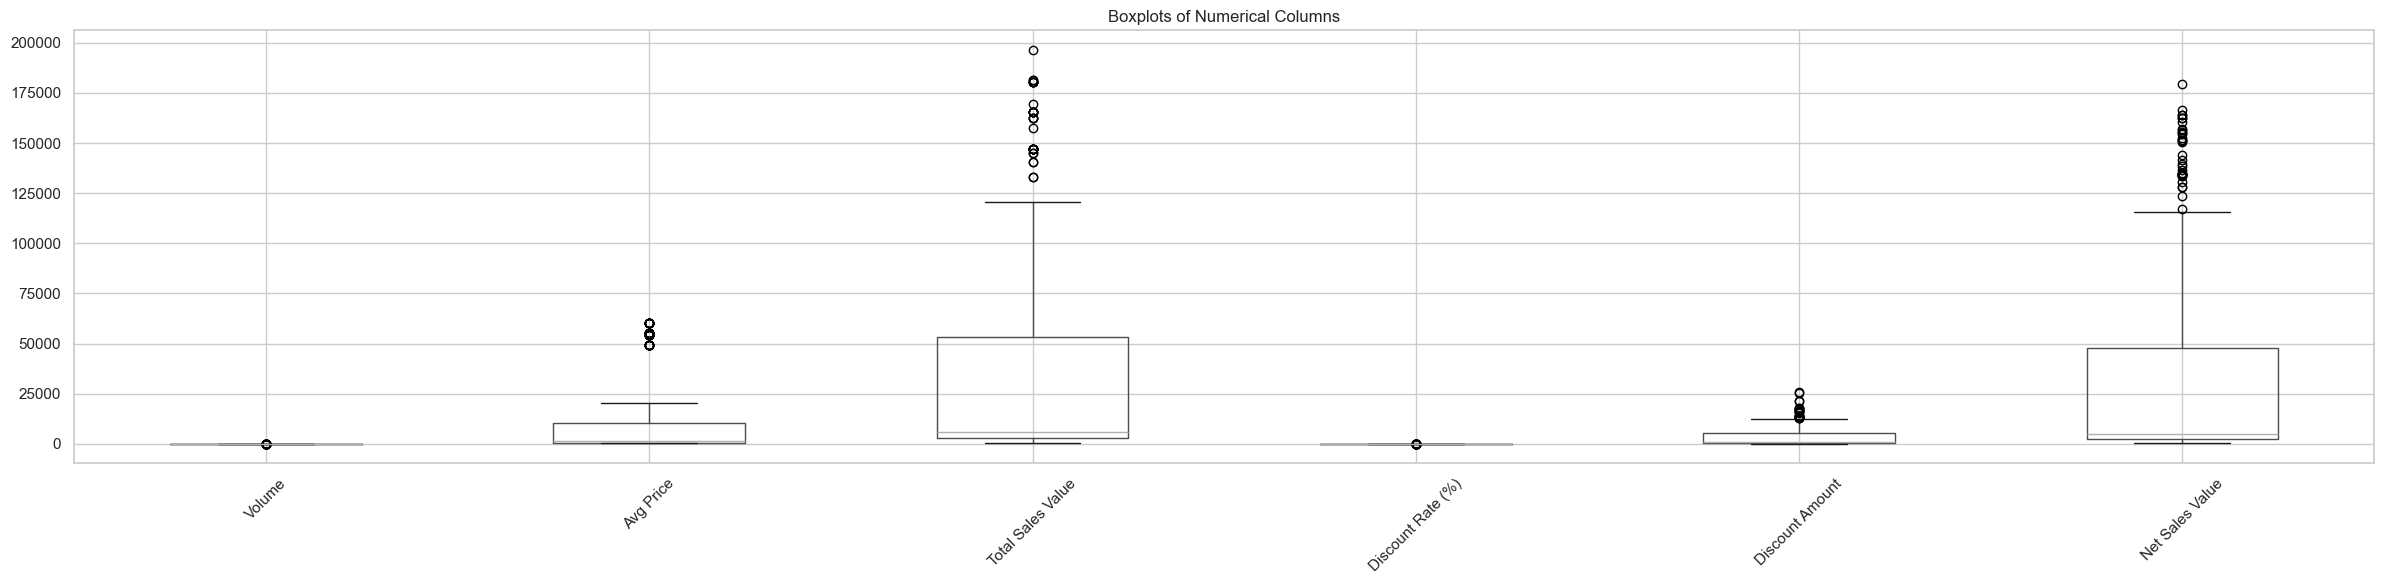

In [10]:
# Box Plots:
''' Creating boxplots for numerical variables to identify outliers and the IQR.'''

plt.figure(figsize=(len(numeric_cols)*4, 6))
df[numeric_cols].boxplot(rot=45, grid=True)
plt.title('Boxplots of Numerical Columns')
plt.tight_layout()
plt.show()

### Bar Chart Analysis for Categorical Column:

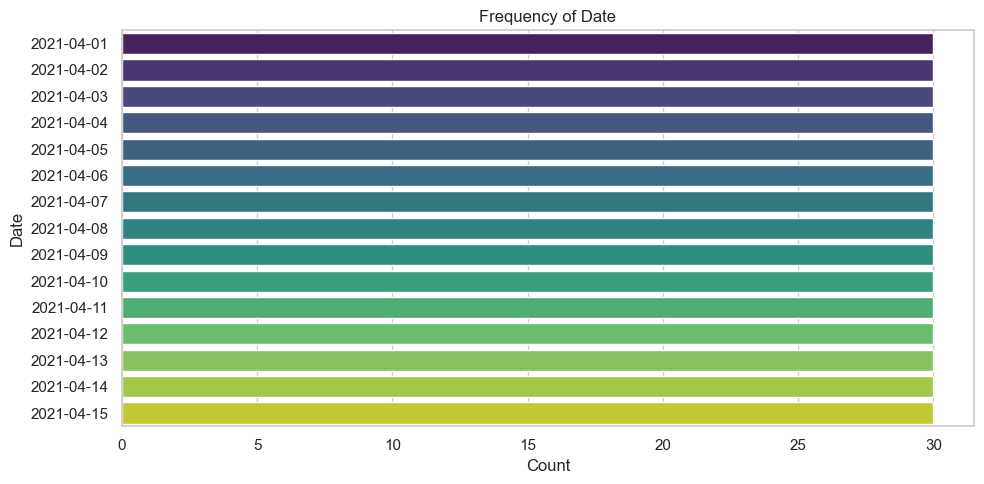

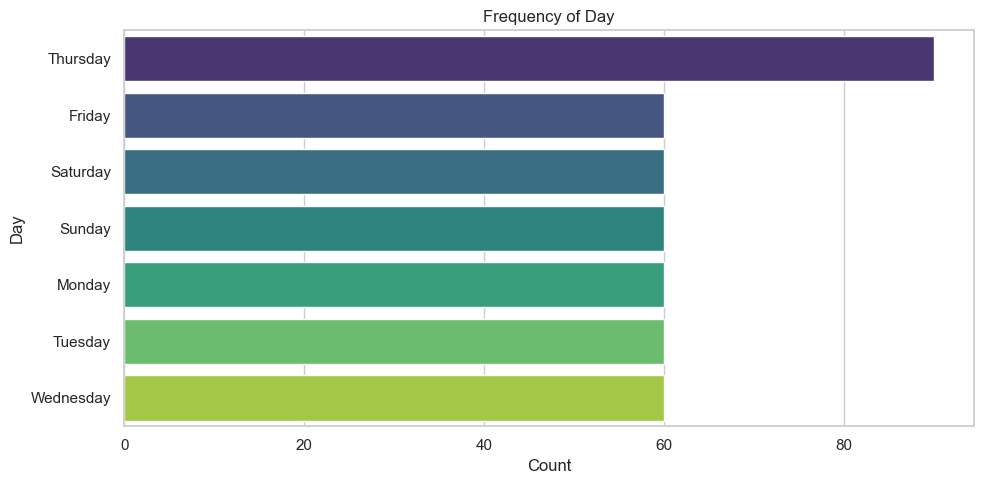

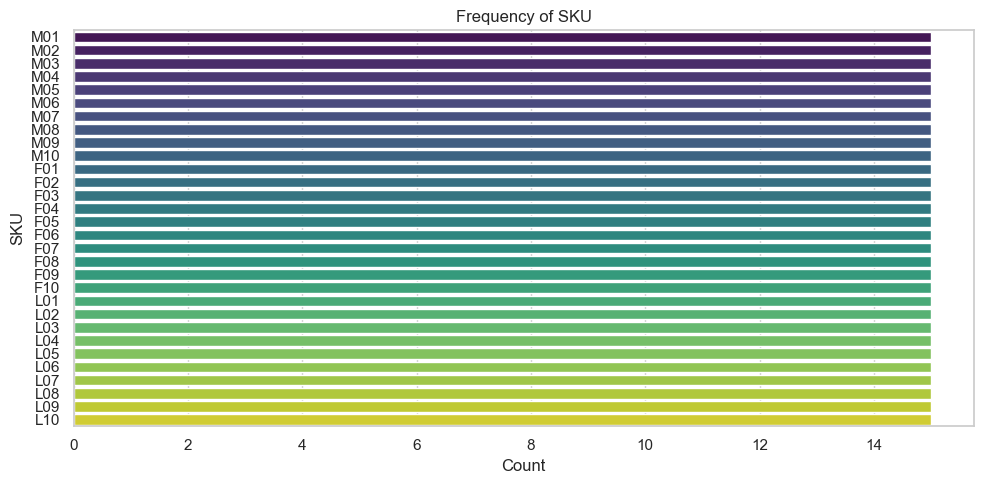

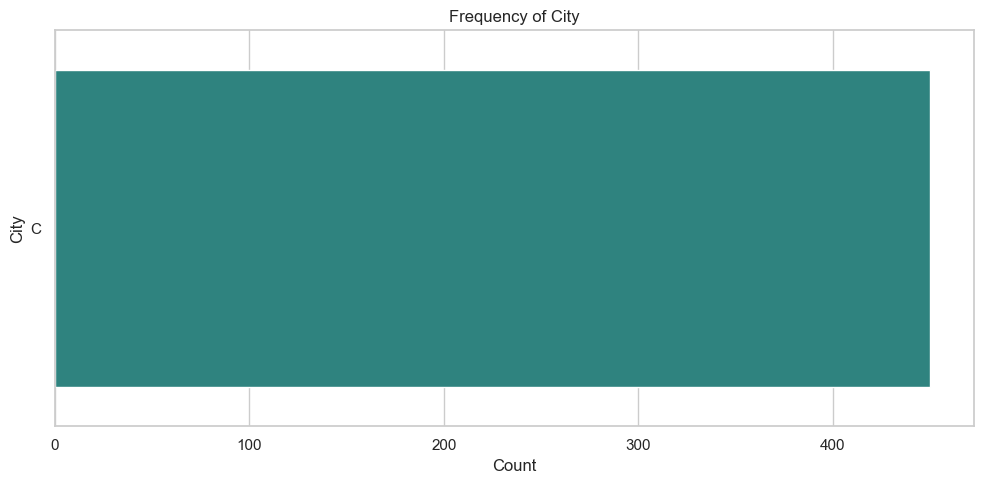

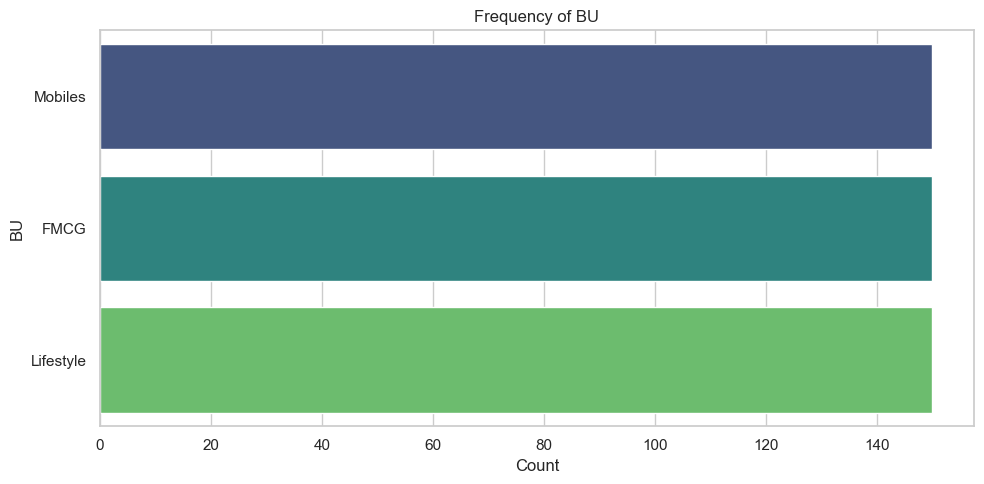

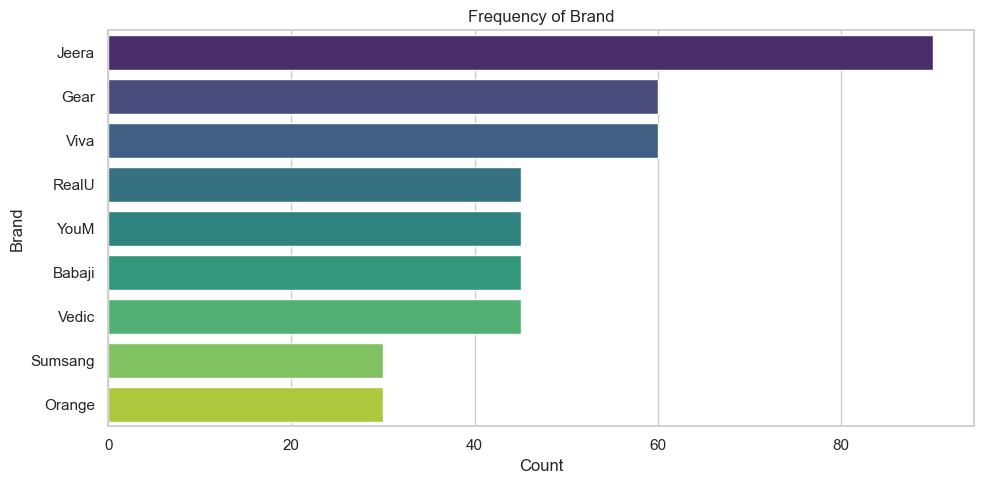

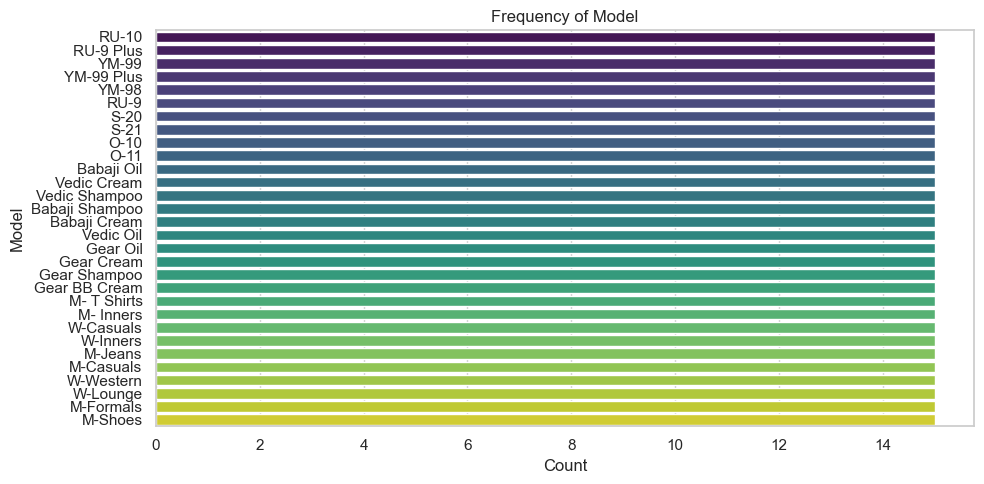

In [11]:
# Bar Charts:
# Creating bar charts for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, palette='viridis')
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Conclusion

In [12]:
# Simple outlier handling (IQR capping) 
def iqr_cap(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series.clip(lower, upper)

df[numeric_cols] = df[numeric_cols].apply(iqr_cap)

#### Summary 
- The descriptive analysis provided a clear understanding of the dataset through key statistical measures such as mean, median, and standard deviation.
- Histograms showed that some numerical variables are right-skewed, indicating occasional high-value sales, while others are more evenly distributed.
- Box plots helped identify outliers and highlighted the spread of the data.
- Bar charts revealed differences in category frequencies, showing which categories contribute most to sales.
- Overall, the dataset is well-structured and suitable for further advanced analysis and modeling.